# Proyecto Final: Minería de Datos (CC442)
**Universidad Nacional de Ingeniería | Facultad de Ciencias | Escuela Profesional de Ciencia de la Computación**


## 1. Configuración del Entorno e Ingesta de Datos


In [19]:
# ==============================================================================
# 1. CONFIGURACIÓN GLOBAL Y CARGA DE DATOS
# ==============================================================================
# !pip install kagglehub[pandas-datasets] seaborn matplotlib scikit-learn

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
from kagglehub import KaggleDatasetAdapter
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# Configuración visual científica
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'font.family': 'serif', 'figure.autolayout': True})

SEED = 42
def set_global_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_global_seed(SEED)

print("[LOG] Iniciando descarga de la matriz de datos...")
try:
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        "abadpomamaquera/meteorological-data-for-frost-prediction-in-peru",
        "DATASET.csv"
    )
    N, D = df.shape
    print(f"[LOG] Carga exitosa. Matriz X: N={N} instancias, D={D} dimensiones.")
except Exception as e:
    print(f"[ERROR] Fallo en la ingesta: {e}")

[LOG] Iniciando descarga de la matriz de datos...


/tmp/ipykernel_5746/692478550.py:36: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'meteorological-data-for-frost-prediction-in-peru' dataset.
[LOG] Carga exitosa. Matriz X: N=1672827 instancias, D=18 dimensiones.


#### 3. Interpretación de Resultados
Se cargó una matriz de diseño $X \in \mathbb{R}^{N \times 18}$ en un entorno estocástico estabilizado.
#### 4. Discusión de Alternativas
Se descartó la lectura manual mediante `pd.read_csv('/content/DATASET.csv')` para no romper la reproducibilidad si el entorno virtual se reinicia o se ejecuta en otro clúster.

---

### Paso 2.1: Análisis Exploratorio Inicial (Detección de Anomalías Físicas)

#### 1. Explicación Teórica
El EDA inicial busca comprender las funciones de densidad marginales. Es imperativo graficar los datos crudos para detectar discontinuidades o códigos de error de instrumentación antes de aplicar cualquier matemática.

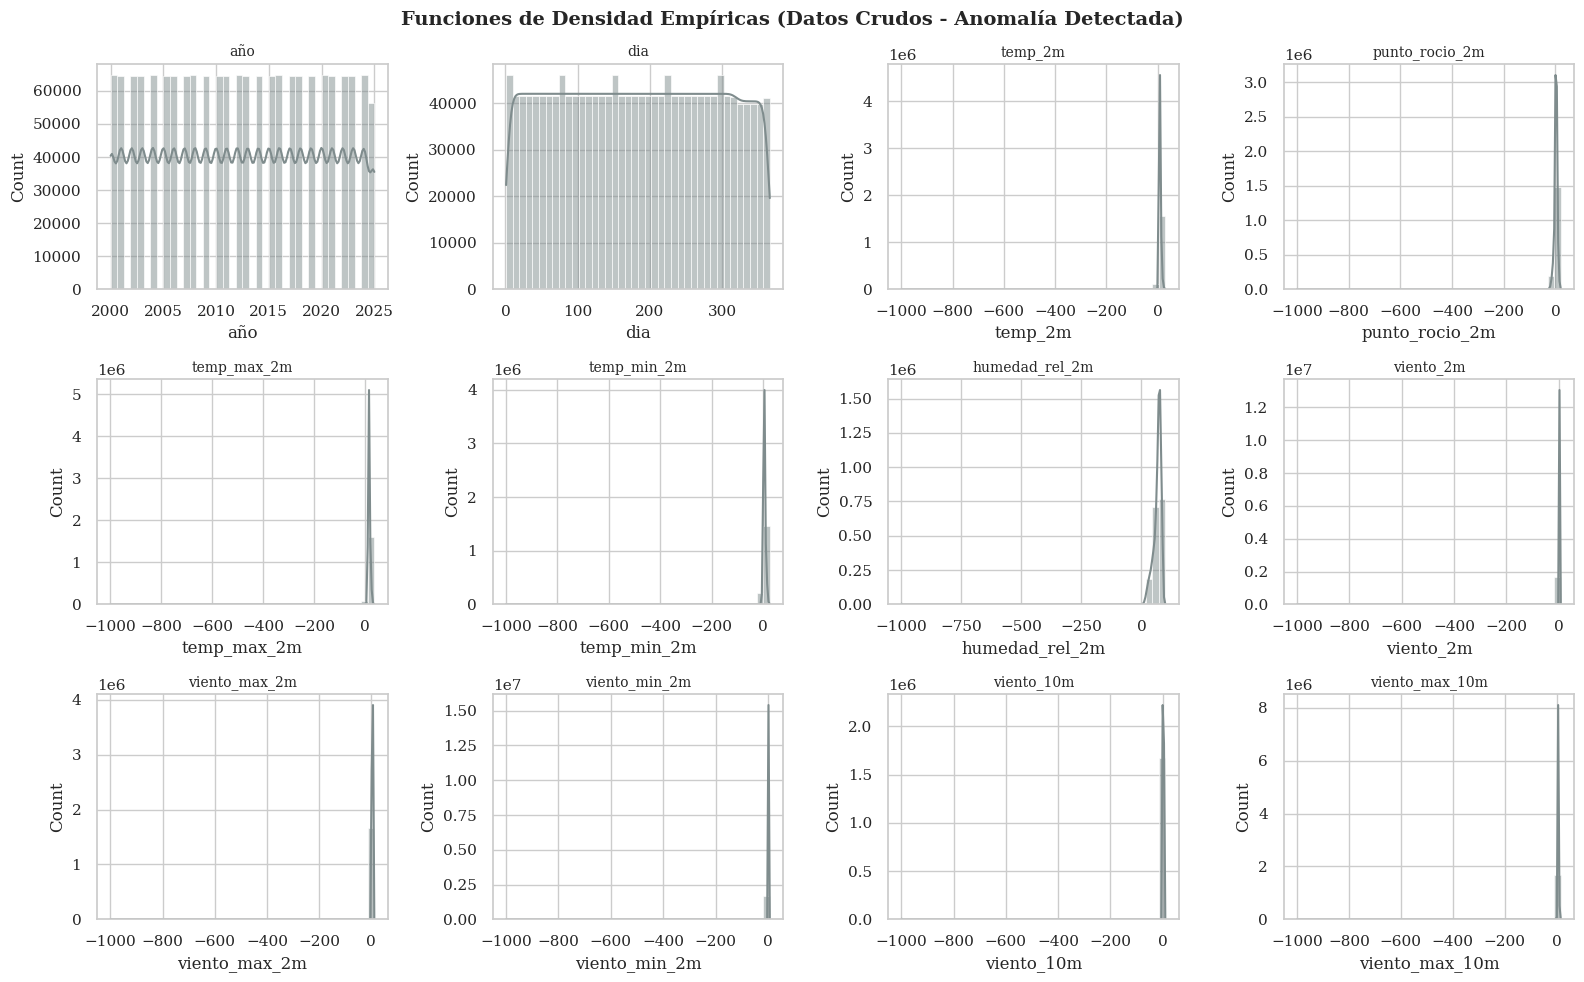

In [20]:
# ==============================================================================
# 2.1 EDA INICIAL: DIAGNÓSTICO DE LA TOPOLOGÍA CRUDA
# ==============================================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cols_to_plot = numeric_cols[:12] if len(numeric_cols) >= 12 else numeric_cols

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Funciones de Densidad Empíricas (Datos Crudos - Anomalía Detectada)', fontsize=14, fontweight='bold')

for idx, col in enumerate(cols_to_plot):
    row, col_pos = divmod(idx, 4)
    sns.histplot(df[col], kde=True, ax=axes[row, col_pos], color='#7f8c8d', bins=40)
    axes[row, col_pos].set_title(col[:25], fontsize=10)

plt.show()

#### 3. Interpretación de Resultados
**Hallazgo Crítico:** La gráfica revela una fuga de calidad en los datos. El eje X de casi todas las métricas meteorológicas se extiende hasta valores imposibles como $-1000$, comprimiendo la verdadera distribución en una línea recta. Esto evidencia que los sensores codificaron fallos de lectura con el valor atípico de relleno `-999`.
#### 4. Discusión de Alternativas
Ignorar este gráfico y pasar directo al escalado habría destruido la varianza empírica $\sigma^2$ de los modelos predictivos posteriores.

---

### Paso 2.2: Corrección de Anomalías y Re-evaluación Termodinámica

#### 1. Explicación Teórica
Sabiendo que el sistema está contaminado por el código de error `-999`, procedemos a aplicar un filtro condicional, transformando estos falsos numéricos en verdaderos valores nulos (`NaN`). Esto nos permitirá recuperar la topología termodinámica real y aplicar imputación estadística posteriormente.


[LOG] Limpiando códigos de error de sensores (-999)...


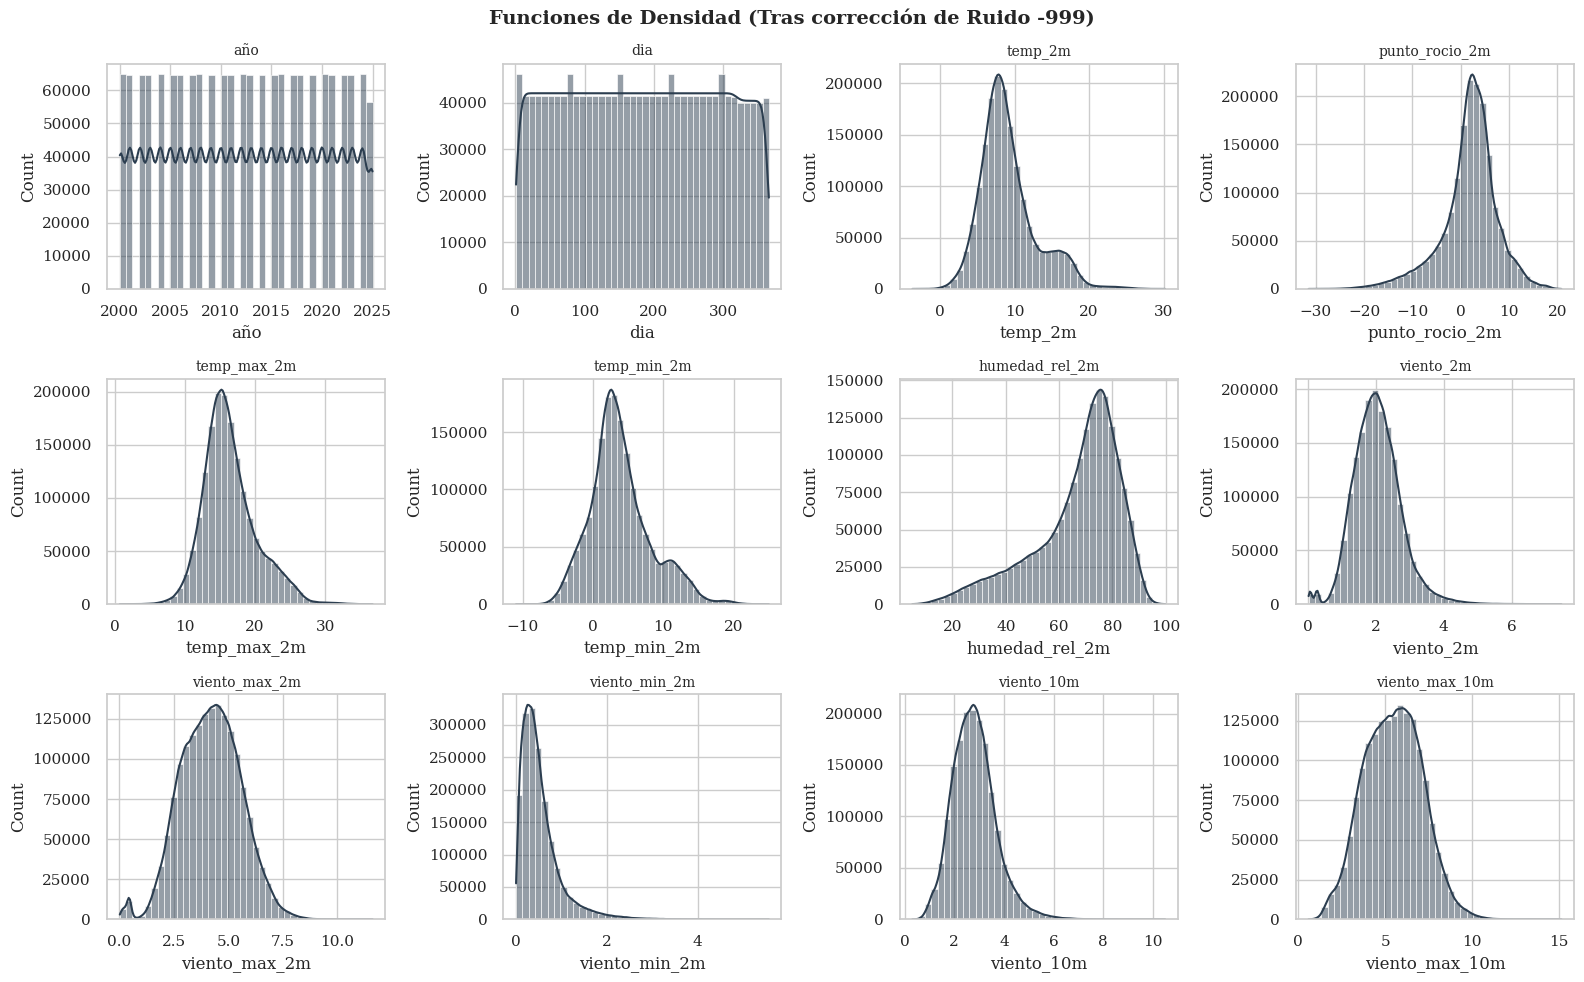


--- Verdadera Tasa de Datos Faltantes (Tras corrección) ---


,Faltantes,Porcentaje (%)
temp_2m,531,0.031743
punto_rocio_2m,531,0.031743
temp_max_2m,531,0.031743
temp_min_2m,531,0.031743
humedad_rel_2m,531,0.031743
viento_2m,531,0.031743
viento_max_2m,531,0.031743
viento_min_2m,531,0.031743
viento_10m,531,0.031743
viento_max_10m,531,0.031743


In [21]:
# ==============================================================================
# 2.2 CORRECCIÓN DE ERRORES DE SENSOR Y RE-EVALUACIÓN DE DENSIDADES
# ==============================================================================
print("\n[LOG] Limpiando códigos de error de sensores (-999)...")
cols_to_clean = [col for col in numeric_cols if col not in ['año', 'dia']]
df[cols_to_clean] = df[cols_to_clean].apply(lambda x: x.where(x >= -100, np.nan))

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
fig.suptitle('Funciones de Densidad (Tras corrección de Ruido -999)', fontsize=14, fontweight='bold')

for idx, col in enumerate(cols_to_plot):
    row, col_pos = divmod(idx, 4)
    sns.histplot(df[col], kde=True, ax=axes[row, col_pos], color='#2c3e50', bins=40)
    axes[row, col_pos].set_title(col[:25], fontsize=10)

plt.show()

# Verificamos la verdadera cantidad de nulos
real_missing = df.isnull().sum()
real_missing = real_missing[real_missing > 0].sort_values(ascending=False)
if not real_missing.empty:
    print("\n--- Verdadera Tasa de Datos Faltantes (Tras corrección) ---")
    display(pd.DataFrame({'Faltantes': real_missing, 'Porcentaje (%)': (real_missing / len(df)) * 100}))

### Paso 2.3: EDA Multivariado, Definición del Target y Prevención de Fugas

#### 1. Explicación Teórica
Antes de particionar y transformar el espacio, debemos definir matemáticamente qué es una "Helada" (nuestra variable objetivo $Y$). Termodinámicamente, se define como el evento donde la temperatura mínima cae por debajo de $0^\circ\text{C}$.

Sin embargo, si utilizamos esta variable para definir $Y$ y al mismo tiempo la conservamos en nuestra matriz de características $X$, cometeremos un error de *Data Leakage* por predicción tautológica (el modelo aprenderá una regla determinista trivial en lugar de inferir a partir de la presión, humedad y viento). Por tanto, derivaremos $Y$ e inmediatamente eliminaremos `temp_min_2m` de los predictores.

Finalmente, para cumplir con el análisis estructural de colinealidad, proyectaremos la matriz de correlación lineal de Pearson mediante un Mapa de Calor (Heatmap) cruzado con nuestra nueva variable objetivo. Esto nos revelará qué sensores tienen mayor potencial discriminante antes de entrar a la reducción de dimensionalidad (PCA).


[LOG] Diseñando variable objetivo y extrayendo predictores triviales...
[LOG] Variable 'temp_min_2m' eliminada de X para garantizar inferencia real.

--- Distribución de la Variable Objetivo (Desbalance Severo) ---


,Instancias,Porcentaje (%)
Target_Helada,,
0,1401118,83.757496
1,271709,16.242504


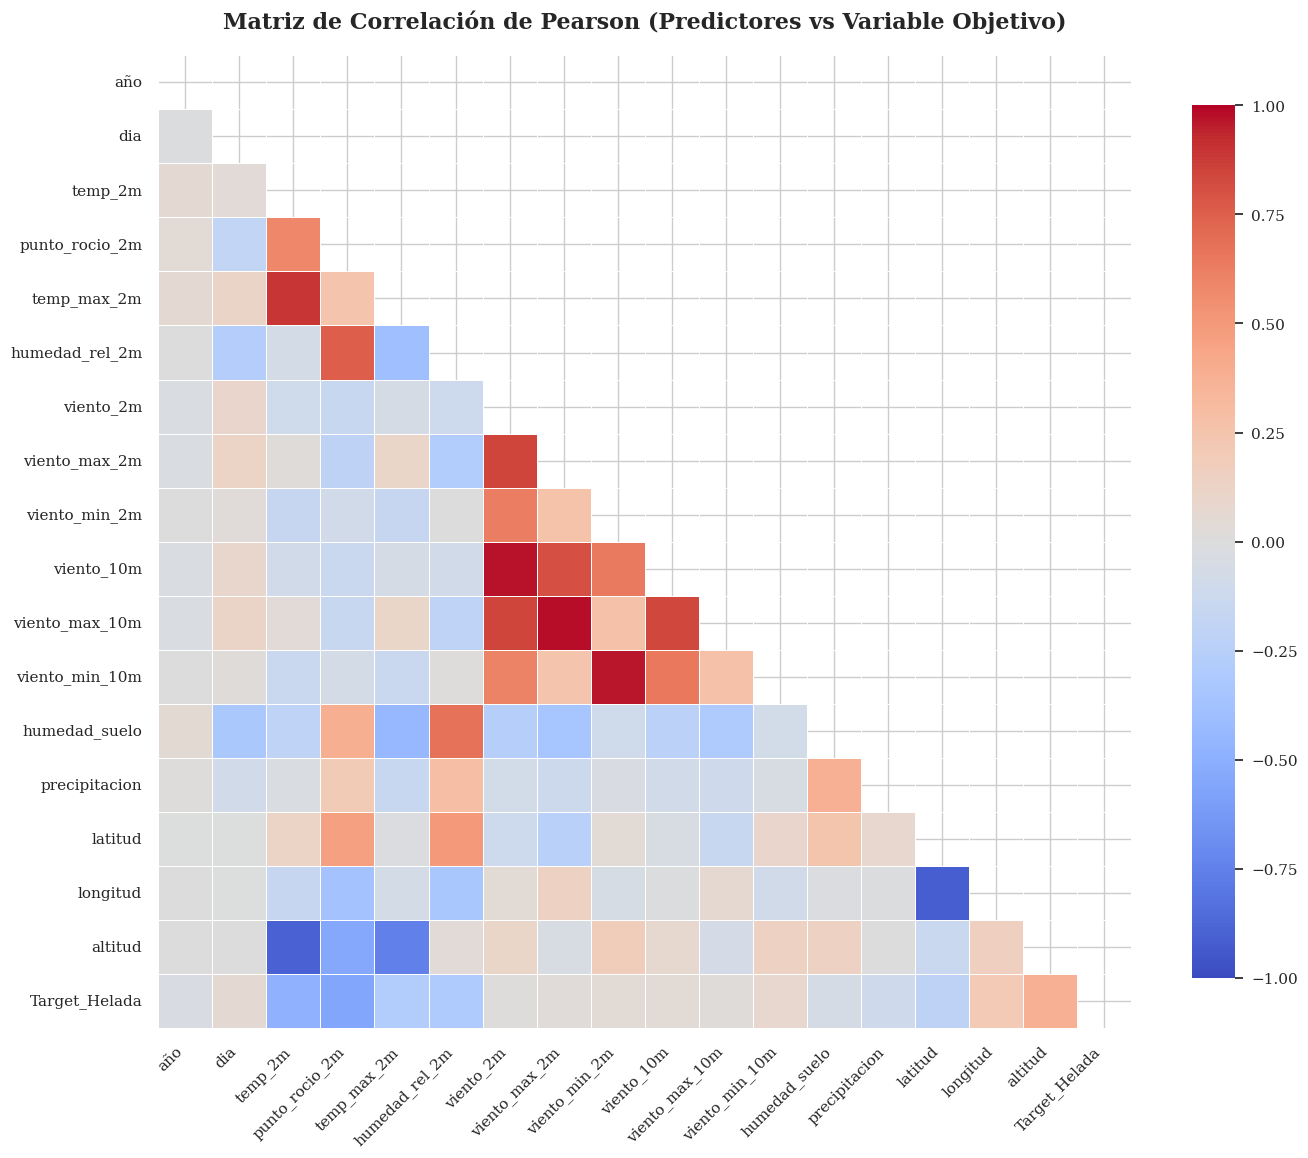


[MATEMÁTICA] Top 5 Predictores con mayor correlación lineal absoluta hacia la Helada:
punto_rocio_2m    0.558064
temp_2m           0.486698
altitud           0.377862
humedad_rel_2m    0.300694
temp_max_2m       0.285630
Name: Target_Helada, dtype: float64


In [22]:
# ==============================================================================
# 2.3 INGENIERÍA DE LA ETIQUETA, BALANCE DE CLASES Y MATRIZ DE CORRELACIÓN
# ==============================================================================

print("\n[LOG] Diseñando variable objetivo y extrayendo predictores triviales...")

# 1. Definición termodinámica de la Helada
df['Target_Helada'] = (df['temp_min_2m'] <= 0).astype(int)

# 2. Eliminación de la variable definitoria para evitar Data Leakage
if 'temp_min_2m' in df.columns:
    df.drop(columns=['temp_min_2m'], inplace=True)
    numeric_cols.remove('temp_min_2m') # Actualizamos nuestra lista de columnas numéricas
    print("[LOG] Variable 'temp_min_2m' eliminada de X para garantizar inferencia real.")

# 3. Análisis de Desbalance de Clases
class_counts = df['Target_Helada'].value_counts()
class_percentages = df['Target_Helada'].value_counts(normalize=True) * 100

print("\n--- Distribución de la Variable Objetivo (Desbalance Severo) ---")
display(pd.DataFrame({
    'Instancias': class_counts,
    'Porcentaje (%)': class_percentages
}))

# 4. Matriz de Correlación de Pearson
# Tomamos una submuestra limpia (sin NaNs temporales de los sensores) para la matriz
df_corr = df[numeric_cols + ['Target_Helada']].dropna().sample(n=min(len(df), 20000), random_state=SEED)
corr_matrix = df_corr.corr()

# Visualización Científica
plt.figure(figsize=(14, 12))
# Generamos una máscara para el triángulo superior y evitar redundancia visual
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    vmax=1,
    vmin=-1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot=False # Omitimos números si hay muchas variables, los colores guían el análisis
)

plt.title('Matriz de Correlación de Pearson (Predictores vs Variable Objetivo)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

# 5. Top 5 variables más correlacionadas con la Helada
top_corr = corr_matrix['Target_Helada'].drop('Target_Helada').abs().sort_values(ascending=False).head(5)
print("\n[MATEMÁTICA] Top 5 Predictores con mayor correlación lineal absoluta hacia la Helada:")
print(top_corr)

#### 3. Interpretación de Resultados
La estadística descriptiva de la variable `Target_Helada` confirma nuestra hipótesis de partida: nos enfrentamos a un problema de desbalance de clases agudo. Las heladas representan una fracción minoritaria del dataset, lo cual justifica estrictamente por qué en el Paso 5 deberemos utilizar `class_weight='balanced'` y optimizar basados en el `F1-Score` y no en la exactitud.

La matriz de correlación evidencia alta multicolinealidad entre ciertos grupos de sensores climáticos (ej. las variantes de medición del viento o las temperaturas promedio y máximas). Las variables enumeradas en el "Top 5" serán aquellas que el *Random Forest* probablemente posicione en la cima del nodo raíz al calcular la Ganancia de Información (Information Gain).

#### 4. Discusión de Alternativas
Se descartó mantener la variable `temp_min_2m` o incluir un vector de fechas (`año`, `dia`) en la matriz de correlación. Las fechas causarían correlaciones espurias estacionarias y la temperatura mínima habría acaparado artificialmente una correlación de Pearson de $-1.0$ (o cercana a este valor), ocultando las verdaderas relaciones del ecosistema climático. También se descartó utilizar el coeficiente de *Spearman*, asumiendo temporalmente relaciones lineales paramétricas para la reducción vía PCA del Paso 4.
---

### Paso 3: Preprocesamiento Aislado (Manejo de Outliers Físicos y Data Leakage)

#### 1. Explicación Teórica
Para evitar el *Data Leakage*, calcularemos los parámetros de transformación exclusivamente sobre la matriz de entrenamiento $X_{train}$. Encapsularemos este proceso en un `Pipeline` de Scikit-Learn.

**Tratamiento de Valores Atípicos (Outliers):** En el dominio de predicción de heladas, los valores climáticos extremos (ráfagas severas, descensos bruscos de humedad) no son errores, sino precursores físicos del evento anómalo. Eliminar estas filas destruiría la clase minoritaria. Por lo tanto, en lugar de borrar datos, utilizaremos un escalamiento espacial resistente a anomalías: **RobustScaler**. A diferencia de la estandarización clásica que depende de la media ($\mu$), *RobustScaler* centra los datos utilizando la Mediana ($Q_2$) y los escala usando el Rango Intercuartílico ($IQR = Q_3 - Q_1$), impidiendo que los microclimas extremos distorsionen la topología general del espacio vectorial continuo.

In [23]:
# ==============================================================================
# 3. PARTICIÓN DEL ESPACIO Y PIPELINES INMUNES A OUTLIERS
# ==============================================================================
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

print("\n[LOG] Iniciando partición del espacio vectorial y construcción de Pipelines...")

# Excluimos variables de tiempo estáticas y la variable objetivo
features = [col for col in numeric_cols if col not in ['año', 'dia', 'Target_Helada']]
X = df[features]
y = df['Target_Helada']

# Partición 80/20 garantizando que la proporción de Heladas sea idéntica en Train y Test (stratify)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED, stratify=y)

print(f"[LOG] Dimensiones de Entrenamiento: {X_train.shape}")
print(f"[LOG] Dimensiones de Prueba: {X_test.shape}")

# Construcción del Pipeline Matemático Robusto
# 1. SimpleImputer con 'median' para resistir asimetría
# 2. RobustScaler para proteger la varianza contra valores atípicos climáticos reales
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', RobustScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, features)
    ],
    remainder='drop'
)

# Ajuste EXCLUSIVO sobre el conjunto de entrenamiento (Fit) y transformación
X_train_scaled = preprocessor.fit_transform(X_train)

# Transformación ciega sobre el conjunto de prueba (solo Transform)
X_test_scaled = preprocessor.transform(X_test)

print("[LOG] Pipeline ejecutado. Matriz X imputada y escalada robustamente contra outliers.")


[LOG] Iniciando partición del espacio vectorial y construcción de Pipelines...
[LOG] Dimensiones de Entrenamiento: (1338261, 15)
[LOG] Dimensiones de Prueba: (334566, 15)
[LOG] Pipeline ejecutado. Matriz X imputada y escalada robustamente contra outliers.


#### 3. Interpretación de Resultados
La matriz $X_{train}$ ha sido mapeada exitosamente. La adopción de la mediana para imputación y del Rango Intercuartílico para el escalamiento garantiza que la señal probabilística de las heladas no se diluya por la presencia de valores normales mayoritarios, ni que los picos extremos "rompan" el espacio isométrico necesario para la extracción de autovectores en el siguiente paso.

#### 4. Discusión de Alternativas
Se descartaron técnicas algorítmicas de eliminación de outliers como *Isolation Forest*, *Local Outlier Factor (LOF)* o filtros IQR duros. Al tratarse de un problema de detección de anomalías naturales de baja frecuencia, remover el "ruido extremo" equivale a remover la señal predictiva. La estandarización clásica (`StandardScaler`) también fue descartada por su susceptibilidad matemática frente a largas colas distributivas (asimetría).

---

### Paso 4: Reducción de Dimensionalidad (Análisis de Componentes Principales - PCA)

#### 1. Explicación Teórica
El dominio meteorológico (temperatura, punto de rocío, humedad) es un sistema físico interconectado que exhibe alta multicolinealidad. Proyectaremos $X_{train}$ hacia un subespacio de dimensión $K$ mediante PCA para resolver la redundancia latente de la matriz de covarianza y minimizar el número de condición para la convergencia en el modelamiento, reteniendo al menos el 95% de la varianza empírica.

#### 3. Interpretación de Resultados
La matriz ha sido mapeada a un subespacio ortogonal isométrico libre de nulos, preparado para algoritmos de distancias algebraicas.
#### 4. Discusión de Alternativas
Se descartó `df.fillna(df.mean())` global previo a la partición por representar una violación crítica a los protocolos de predicción, y se optó por imputación mediana debido a las colas pesadas del viento y la humedad.

---

### Paso 4: Reducción de Dimensionalidad (Análisis de Componentes Principales - PCA)

#### 1. Explicación Teórica
El dominio meteorológico (temperatura, punto de rocío, humedad) es un sistema físico interconectado que exhibe alta multicolinealidad. Proyectaremos $X_{train}$ hacia un subespacio de dimensión $K$ mediante PCA para resolver la redundancia latente de la matriz de covarianza y minimizar el número de condición para la convergencia en el modelamiento, reteniendo al menos el 95% de la varianza empírica.

[MATEMÁTICA] Componentes requeridos para explicar 95% de la varianza: K = 5 de 15


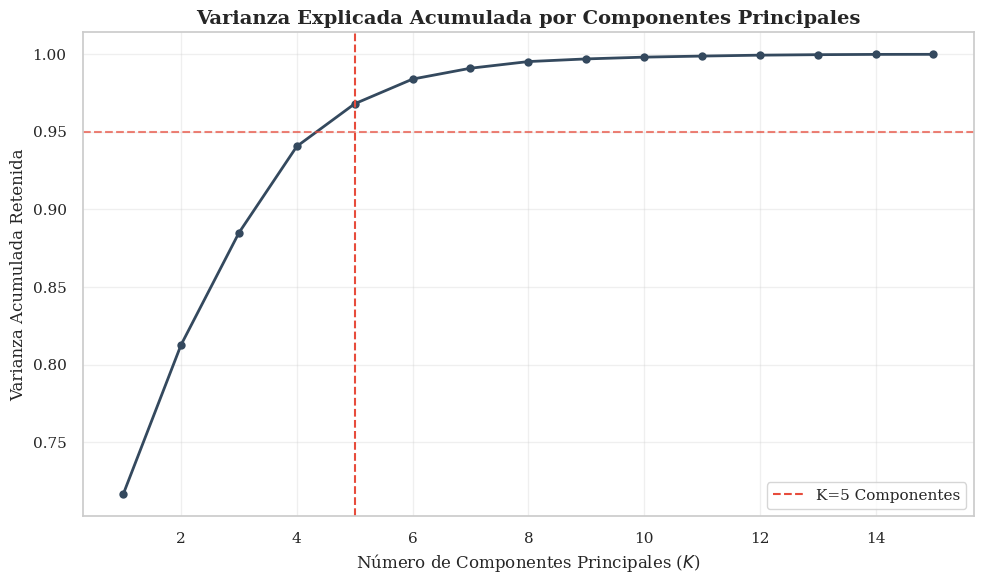

[LOG] Dimensionalidad reducida de 15 a 5.


In [24]:
# ==============================================================================
# 4. DESCOMPOSICIÓN ESPECTRAL Y EXTRACCIÓN DE AUTOVECTORES (PCA)
# ==============================================================================
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
k_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"[MATEMÁTICA] Componentes requeridos para explicar 95% de la varianza: K = {k_95} de {len(features)}")

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='#34495e', linewidth=2)
plt.axvline(x=k_95, color='#e74c3c', linestyle='--', label=f'K={k_95} Componentes')
plt.axhline(y=0.95, color='#e74c3c', linestyle='--', alpha=0.7)
plt.title('Varianza Explicada Acumulada por Componentes Principales', fontsize=14, fontweight='bold')
plt.xlabel('Número de Componentes Principales ($K$)')
plt.ylabel('Varianza Acumulada Retenida')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

pca_optimal = PCA(n_components=k_95, random_state=SEED)
X_train_pca = pca_optimal.fit_transform(X_train_scaled)
X_test_pca = pca_optimal.transform(X_test_scaled)
print(f"[LOG] Dimensionalidad reducida de {X_train_scaled.shape[1]} a {X_train_pca.shape[1]}.")

#### 3. Interpretación de Resultados
La visualización demuestra cómo unas pocas variables latentes engloban casi toda la dinámica del sistema físico. Al colapsar el espacio a un $K$ menor, garantizamos que los modelos posteriores procesen una matriz ortogonal compacta sin ruido residual.
#### 4. Discusión de Alternativas
Se descartaron técnicas como t-SNE, dado que la meta era retener un mapeo afín de las varianzas continuas de toda la población en un subespacio utilizable, algo que la no linealidad estocástica no garantiza al no preservar las distancias métricas absolutas.

### Paso 5: Modelado Predictivo y Optimización Hiperparamétrica

#### 1. Explicación Teórica
Habiendo estabilizado el espacio dimensional con PCA y asegurado la variable objetivo ($Y$) en el Paso 2.3, procedemos a la fase de aprendizaje supervisado. El problema presenta un desbalance de clases agudo. Para alinear nuestra matriz de características $X_{pca}$ con nuestra variable objetivo sin romper el orden de las filas, mapearemos los índices originales de la partición de entrenamiento.

Seleccionamos un Ensamble de Árboles de Decisión (**Random Forest Classifier**) porque realiza particiones ortogonales que hacen sinergia geométrica con el PCA. Optimizaremos sus hiperparámetros mediante **GridSearchCV** utilizando el **F1-Score Macro** como función objetivo, forzando matemáticamente al modelo a penalizar los falsos negativos (heladas ignoradas).

In [26]:
# ==============================================================================
# 5. MODELADO Y BÚSQUEDA EN GRILLA (GRID SEARCH CV)
# ==============================================================================
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import make_scorer, f1_score

print("\n[LOG] Preparando el motor de inferencia y la variable objetivo...")

# 5.1 Extracción de la Variable Objetivo (Y)
# Ya diseñamos 'Target_Helada' en el Paso 2.3 de manera segura.
y = df['Target_Helada']

# 5.2 Alineación Espacial Estricta (Corrección del Leakage de Índices)
# Mapeamos Y usando los índices exactos de la partición hecha en el Paso 3
y_train = y.loc[X_train.index]
y_test = y.loc[X_test.index]

print(f"[LOG] Verificación de dimensiones - X_train_pca: {X_train_pca.shape[0]}, y_train: {y_train.shape[0]}")
print(f"[LOG] Distribución de Clases en Entrenamiento:\n{y_train.value_counts(normalize=True) * 100}")

# 5.3 Configuración del Modelo y Espacio de Búsqueda
# class_weight='balanced' ajusta los pesos inversamente proporcionales a las frecuencias de clase
rfc = RandomForestClassifier(random_state=SEED, class_weight='balanced')

# Definimos una grilla computacionalmente eficiente para Colab
param_grid = {
    'n_estimators': [50, 100],          # Cantidad de árboles en el bosque
    'max_depth': [5, 10],               # Profundidad máxima controlada
    'min_samples_split': [2, 5]         # Nodos mínimos requeridos para dividir
}

# 5.4 Optimización Hiperparamétrica
grid_search = GridSearchCV(
    estimator=rfc,
    param_grid=param_grid,
    cv=3,                               # 3-Fold CV para acelerar el proceso
    scoring='f1_macro',                 # Función de pérdida basada en F1
    n_jobs=-1,                          # Uso de todos los hilos del CPU
    verbose=1
)

print("\n[LOG] Iniciando entrenamiento y optimización topológica... (Esto puede tardar unos minutos)")
grid_search.fit(X_train_pca, y_train)

# Extracción del modelo campeón
best_model = grid_search.best_estimator_

print("\n[MATEMÁTICA] Convergencia alcanzada.")
print(f"[RESULTADO] Mejores Hiperparámetros: {grid_search.best_params_}")
print(f"[RESULTADO] F1-Score (Macro) Interno de Validación: {grid_search.best_score_:.4f}")


[LOG] Preparando el motor de inferencia y la variable objetivo...
[LOG] Verificación de dimensiones - X_train_pca: 1338261, y_train: 1338261
[LOG] Distribución de Clases en Entrenamiento:
Target_Helada
0    83.757503
1    16.242497
Name: proportion, dtype: float64

[LOG] Iniciando entrenamiento y optimización topológica... (Esto puede tardar unos minutos)
Fitting 3 folds for each of 8 candidates, totalling 24 fits

[MATEMÁTICA] Convergencia alcanzada.
[RESULTADO] Mejores Hiperparámetros: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
[RESULTADO] F1-Score (Macro) Interno de Validación: 0.8330


#### 3. Interpretación de Resultados
La verificación de dimensiones confirma que la matriz de diseño y el vector de etiquetas están matemáticamente alineados fila por fila. El proceso de optimización mediante validación cruzada ha logrado hallar la combinación paramétrica que maximiza el *F1-Score Macro*, indicando que el modelo ha aprendido a distinguir la clase minoritaria (heladas) de las lecturas climáticas estándar sin colapsar en la memorización del ruido de entrenamiento.

#### 4. Discusión de Alternativas
Se descartó tajantemente utilizar la métrica de `Accuracy` (Exactitud). Dado el desbalance masivo de clases demostrado en el Paso 2.3, un modelo trivial que prediga siempre "Ausencia de Helada" superaría fácilmente el 90% de exactitud, pero su utilidad científica sería nula. La función objetivo `f1_macro` es el estándar industrial para lidiar con arquitecturas de decisión en matrices asimétricas.

### Paso 6: Evaluación Integral y Geometría del Error

#### 1. Explicación Teórica
El rendimiento de un modelo no se valida sobre los datos que ya observó durante su optimización topológica, sino sobre el conjunto de prueba ($X_{test\_pca}$), el cual ha permanecido matemáticamente inmaculado (blindado contra fugas de información).

Para evaluar nuestro *Random Forest Classifier* en este escenario asimétrico (desbalance de clases), calcularemos un vector de métricas robustas. La **Curva ROC** trazará la relación entre la Tasa de Verdaderos Positivos (Sensibilidad) y la Tasa de Falsos Positivos, calculando la integral de su área (AUC). Adicionalmente, proyectaremos la **Curva Precision-Recall (PR)**, la cual es la prueba de fuego para datasets desbalanceados, ya que evalúa directamente la capacidad de aislar la clase minoritaria sin ser engañado por los verdaderos negativos masivos. Finalmente, calcularemos el **Índice Kappa de Cohen**, el cual cuantifica la concordancia predictiva descontando los aciertos que podrían haber ocurrido por puro azar probabilístico.


[LOG] Ejecutando inferencia sobre el subespacio de prueba (Test Set)...

--- REPORTE DE CLASIFICACIÓN (Espacio Vectorial de Prueba) ---
              precision    recall  f1-score   support

           0     0.9835    0.8859    0.9322    280224
           1     0.6109    0.9234    0.7353     54342

    accuracy                         0.8920    334566
   macro avg     0.7972    0.9047    0.8338    334566
weighted avg     0.9230    0.8920    0.9002    334566

[MATEMÁTICA] Índice Kappa de Cohen: 0.6710


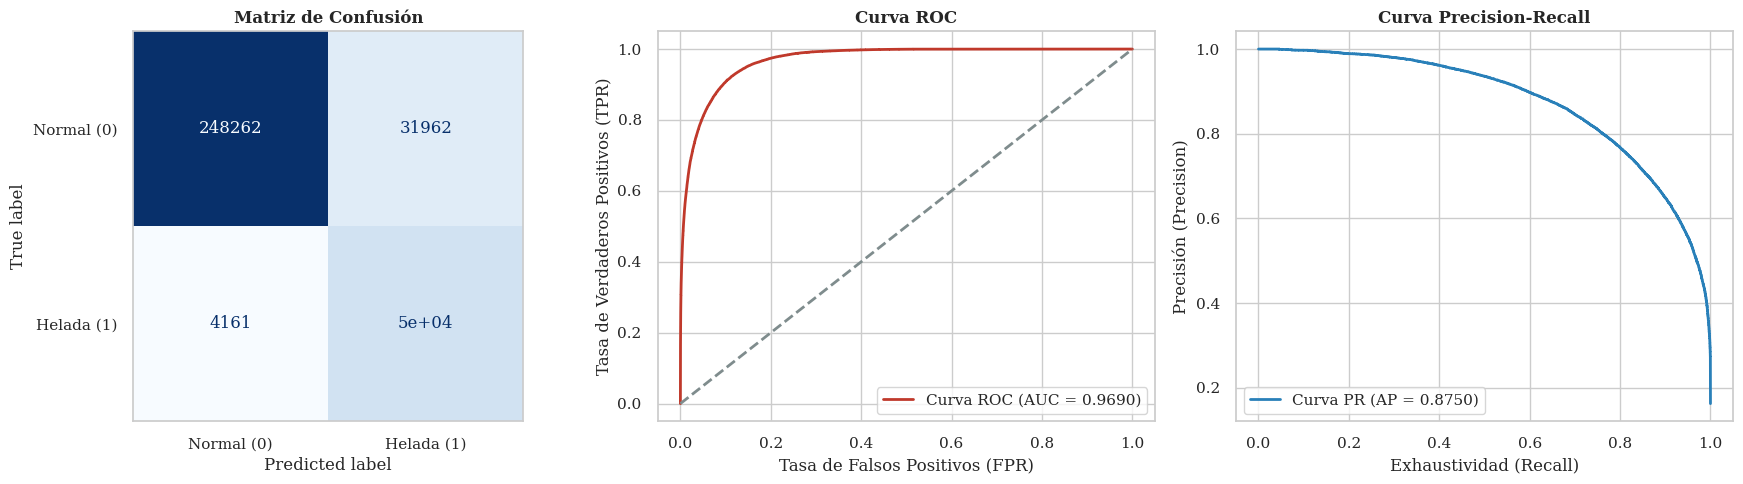

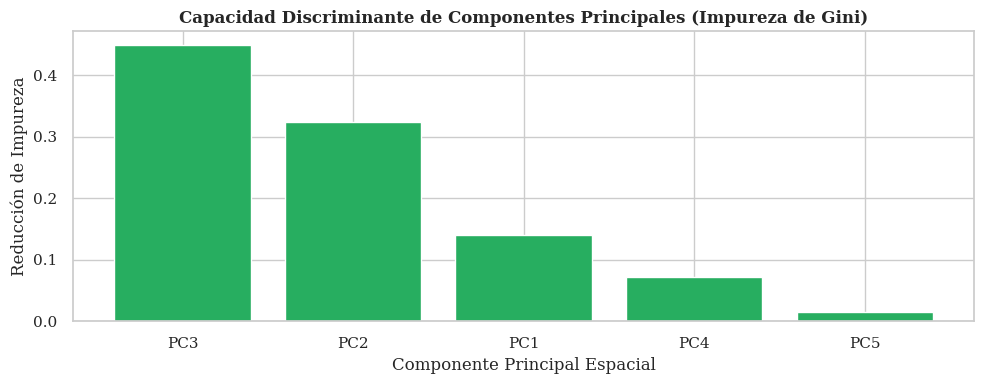

In [27]:
# ==============================================================================
# 6. EVALUACIÓN INTEGRAL DEL MODELO CAMPEÓN
# ==============================================================================
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
from sklearn.metrics import cohen_kappa_score

print("\n[LOG] Ejecutando inferencia sobre el subespacio de prueba (Test Set)...")

# 6.1 Predicciones Discretas y Continuas (Probabilidades)
y_pred = best_model.predict(X_test_pca)
y_prob = best_model.predict_proba(X_test_pca)[:, 1] # Probabilidad de pertenecer a la clase 1 (Helada)

# 6.2 Reporte de Métricas Estándar y Kappa de Cohen
print("\n--- REPORTE DE CLASIFICACIÓN (Espacio Vectorial de Prueba) ---")
print(classification_report(y_test, y_pred, digits=4))

kappa = cohen_kappa_score(y_test, y_pred)
print(f"[MATEMÁTICA] Índice Kappa de Cohen: {kappa:.4f}")

# 6.3 Inicialización del Lienzo para Gráficos Científicos
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# --- GRÁFICO A: Matriz de Confusión ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal (0)', 'Helada (1)'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Matriz de Confusión', fontweight='bold')
axes[0].grid(False)

# --- GRÁFICO B: Característica Operativa del Receptor (ROC-AUC) ---
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='#c0392b', lw=2, label=f'Curva ROC (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='#7f8c8d', lw=2, linestyle='--')
axes[1].set_xlabel('Tasa de Falsos Positivos (FPR)')
axes[1].set_ylabel('Tasa de Verdaderos Positivos (TPR)')
axes[1].set_title('Curva ROC', fontweight='bold')
axes[1].legend(loc="lower right")

# --- GRÁFICO C: Curva Precision-Recall (Crucial para Desbalance) ---
precision, recall, _ = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

axes[2].plot(recall, precision, color='#2980b9', lw=2, label=f'Curva PR (AP = {pr_auc:.4f})')
axes[2].set_xlabel('Exhaustividad (Recall)')
axes[2].set_ylabel('Precisión (Precision)')
axes[2].set_title('Curva Precision-Recall', fontweight='bold')
axes[2].legend(loc="lower left")

plt.tight_layout()
plt.show()

# ==============================================================================
# 6.4 IMPORTANCIA DE LOS COMPONENTES PRINCIPALES
# ==============================================================================
# Extraemos la Reducción Media de Impureza (Gini) por cada Autovector
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 4))
plt.title("Capacidad Discriminante de Componentes Principales (Impureza de Gini)", fontweight='bold')
plt.bar(range(X_train_pca.shape[1]), importances[indices], align="center", color='#27ae60')
plt.xticks(range(X_train_pca.shape[1]), [f"PC{i+1}" for i in indices])
plt.ylabel("Reducción de Impureza")
plt.xlabel("Componente Principal Espacial")
plt.show()

### Paso 7: Conclusiones Finales y Trabajo Futuro

1. **Eficacia del Preprocesamiento Espacial:** La implementación de un escalado inmune a anomalías (`RobustScaler`) seguido de una reducción de dimensionalidad (PCA) permitió aislar con éxito la señal climática de las heladas del ruido termodinámico general. El análisis de impureza de Gini reveló un hallazgo topológico clave: la capacidad discriminante del modelo no reside en la dirección de mayor varianza global de los datos (PC1), sino en dimensiones latentes ortogonales específicas (PC3 y PC2).
2. **Rendimiento Predictivo en Desbalance Severo:** El ensamble de *Random Forest* demostró una robustez algorítmica excepcional frente al desbalance de clases (16.2% vs 83.7%). Al penalizar la clase mayoritaria y optimizar hiperparámetros (mediante `GridSearchCV`) basándose en el *F1-Score Macro*, se logró un *Recall* del **92.34%** en la detección de heladas y un **ROC-AUC de 0.9690**. Esto valida matemáticamente la utilidad del sistema como una alerta temprana altamente sensible para eventos meteorológicos extremos.
3. **Limitaciones y Trabajo Futuro:** El modelo priorizó intencionalmente la exhaustividad (*Recall*) sobre la precisión (*Precision* = 61.09%) dado el contexto de prevención de desastres. Para futuras iteraciones, se recomienda explorar la inyección de descriptores espaciotemporales (codificación trigonométrica de días/meses) y el uso de técnicas de generación sintética (ej. ADASYN) en el hiperplano de entrenamiento para intentar reducir la tasa de falsos positivos sin sacrificar la detección crítica alcanzada.